In [73]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SRC = "/home/gopontarolo/computer-vision/TF/chess-detection/Datasets/chess_piece/test/images/cfc306bf86176b92ffc1afbb98d7896f_jpg.rf.4423638c782bb0d9751f1a14072fdbb4.jpg"
MODEL_PATH =  "./chess-dectection-best-100epc.pt"

In [74]:
class ChessDetector():
    def __init__(self, model_path):
        self.model = YOLO(model_path)
        self.chess_pieces_names = self.model.names

    def detect(self, image, iou=0.1, conf=0.1):
        results = self.model.predict(source=image, 
                                    augment=True, 
                                    iou=iou, 
                                    conf=conf, 
                                    device='cuda:0')
        chess_pieces = []
        for result in results[0].boxes:
            chess_piece = self.chess_pieces_names[int(result.cls.item())]
            
            # Get bottom center of the bounding box
            x1, y1, x2, y2 = map(int, result.xyxy[0])
            cx = int((x1 + x2) // 2)
            cy = int(y2 - ((y2 - y1) * 0.25))  # Center at the bottom
            
            chess_pieces.append((chess_piece, (cx, cy))) 

        return chess_pieces

def show_image(image):
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

detector = ChessDetector(MODEL_PATH)
image = cv2.imread(IMG_SRC)

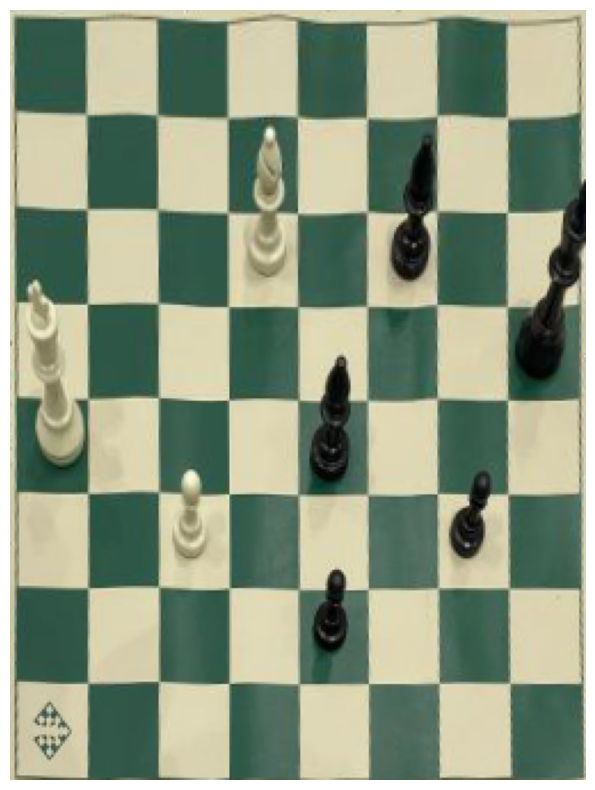

In [75]:
# Correct perspective
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)
dilated = cv2.dilate(edges, None, iterations=2)

# Find contours
board_contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
squares = []
for contour in board_contours:
    if cv2.contourArea(contour) < 4000:
        continue

    poly = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
    if len(poly) == 4:
        squares.append(poly)

square = sorted(squares, key=cv2.contourArea, reverse=True)[0]
square_img = cv2.drawContours(image.copy(), [square], -1, (0, 255, 0), 3)

# Perspective transform

def order_points(points: np.ndarray) -> np.ndarray:
    
    # calculate the sum and difference of the points
    points = points.reshape(4, 2)
    sum_points = points.sum(axis=1)
    diff_points = np.diff(points, axis=1)

    top_right = points[np.argmin(diff_points)]  # point with smallest difference
    top_left = points[np.argmin(sum_points)]    # point with smallest sum
    bottom_left = points[np.argmax(diff_points)] # point with largest difference
    bottom_right = points[np.argmax(sum_points)] # point with largest sum
    
    # return order of co-ordinates.
    return np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")

def calculate_target_points(points: np.ndarray) -> list[np.ndarray]:
    (top_left, top_right, bottom_right, bottom_left) = points

    # calculate the new width and height using euclidean distance
    left_height = np.sqrt(((top_left[0] - bottom_left[0]) ** 2) + ((top_left[1] - bottom_left[1]) ** 2))
    right_height = np.sqrt(((top_right[0] - bottom_right[0]) ** 2) + ((top_right[1] - bottom_right[1]) ** 2))
    top_width = np.sqrt(((top_right[0] - top_left[0]) ** 2) + ((top_right[1] - top_left[1]) ** 2))
    bottom_width = np.sqrt(((bottom_right[0] - bottom_left[0]) ** 2) + ((bottom_right[1] - bottom_left[1]) ** 2))

    min_height = min(int(left_height), int(right_height))
    min_width = min(int(top_width), int(bottom_width))

    target_points = np.array([
        [0, 0],
        [min_width - 1, 0],
        [min_width - 1, min_height - 1],
        [0, min_height - 1]], dtype="float32")

    return target_points

def warp_square(frame: np.ndarray, ordered_points: np.ndarray, target_points: list[np.ndarray]) -> np.ndarray:
    transformation_matrix = cv2.getPerspectiveTransform(ordered_points, target_points)
    height = int(target_points[2][1] - target_points[0][1])
    width = int(target_points[1][0] - target_points[0][0])
    return cv2.warpPerspective(frame, transformation_matrix, (width, height))


ordered_points = order_points(square)
target_points = calculate_target_points(ordered_points)

chessboard = warp_square(image, ordered_points, target_points)
show_image(chessboard)


In [76]:

print("Image shape:", chessboard.shape)
detected_pieces = detector.detect(chessboard)
print("Detected chess pieces:", detected_pieces)

Image shape: (337, 252, 3)

0: 640x480 2 black-bishops, 1 black-king, 2 black-pawns, 1 white-bishop, 1 white-king, 1 white-pawn, 56.8ms
Speed: 2.6ms preprocess, 56.8ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 480)
Detected chess pieces: [('black-king', (235, 140)), ('white-bishop', (111, 101)), ('black-pawn', (200, 231)), ('black-bishop', (176, 102)), ('white-pawn', (78, 231)), ('white-king', (19, 180)), ('black-pawn', (139, 272)), ('black-bishop', (139, 193))]


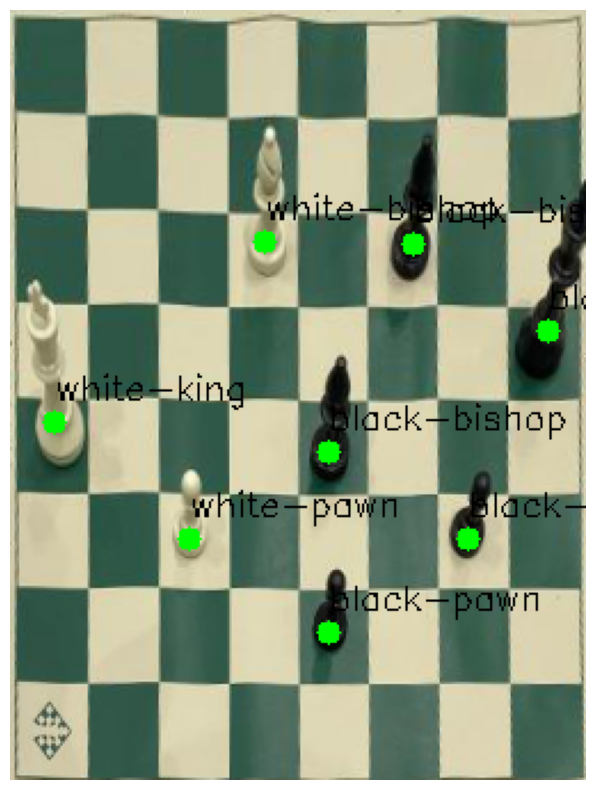

In [77]:
annotated_img = chessboard.copy()
for piece, (cx, cy) in detected_pieces:
    cv2.circle(annotated_img, (cx, cy), 5, (0, 255, 0), -1)
    cv2.putText(annotated_img, piece, (cx, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

show_image(annotated_img)

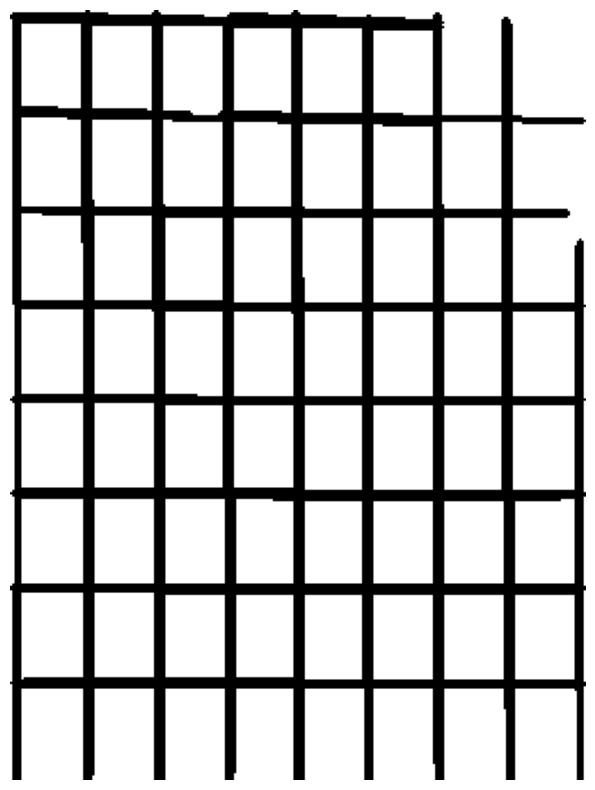

In [78]:
# Find checkerboard squares
grayscale_img = cv2.cvtColor(chessboard, cv2.COLOR_BGR2GRAY)
blurred_img = cv2.GaussianBlur(grayscale_img, (5, 5), 0)
ret, otsu = cv2.threshold(blurred_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
edges = cv2.Canny(blurred_img, 20, 255)
dilated_edges = cv2.dilate(edges, None, iterations=1)
lines = cv2.HoughLinesP(dilated_edges, 1, np.pi / 180, threshold=100, minLineLength=75, maxLineGap=10)
lines_img = np.zeros_like(chessboard)
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(lines_img, (x1, y1), (x2, y2), (255, 255, 255), 2)

inverted_lines_img = cv2.bitwise_not(lines_img)
inverted_lines_img = cv2.cvtColor(inverted_lines_img, cv2.COLOR_BGR2GRAY)
show_image(inverted_lines_img)


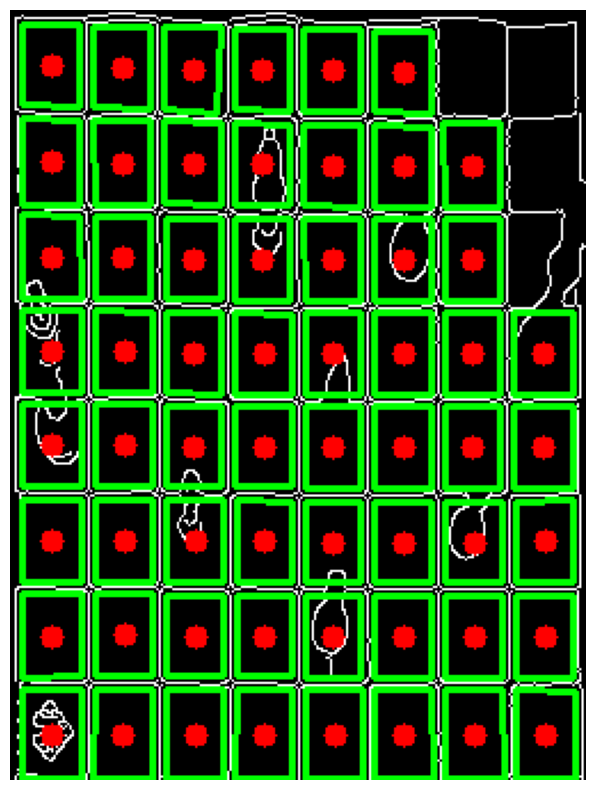

In [79]:
board_contours, hierarchy = cv2.findContours(inverted_lines_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

board_squared = edges.copy()
board_squared = cv2.cvtColor(board_squared, cv2.COLOR_GRAY2BGR)  
square_centers = []
for contour in board_contours:
    if 50 < cv2.contourArea(contour) < 5000:
        # Approximate the contour to a simpler shape
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        # Ensure the approximated contour has 4 points (quadrilateral)
        if len(approx) == 4:
            x, y, w, h = cv2.boundingRect(contour)
            center_x = int((x + (x + w)) / 2)
            center_y = int((y + (y + h)) / 2)

            square_centers.append([center_x,center_y])

            # Draw the contour and center point
            cv2.drawContours(board_squared, [approx], -1, (0, 255, 0), 2)
            cv2.circle(board_squared, (center_x, center_y), 5, (0, 0, 255), -1)

show_image(board_squared)

In [80]:
# Group into cols 
y_sorted = sorted(square_centers, key=lambda y: y[1])
board_rows = []
current_row = [y_sorted[0]]
for coord in y_sorted[1:]:
    if abs(coord[1] - current_row[-1][1]) < 10:  # Adjusted threshold for grouping
        current_row.append(coord)
    else:
        board_rows.append(current_row)
        current_row = [coord]
board_rows.append(current_row)

import random

# Sort columns within each row
for i in range(len(board_rows)):
    board_rows[i] = sorted(board_rows[i], key=lambda x: x[0])
    # drop a random column to test
    drop_idx = random.randint(0, len(board_rows[i]) - 1) if len(board_rows[i]) > 2 else None
    if drop_idx is not None:
        board_rows[i].pop(drop_idx)

for row in board_rows:
    print("Row:", row)
        


Row: [[18, 24], [49, 25], [80, 26], [110, 26], [172, 27]]
Row: [[18, 66], [49, 67], [80, 67], [110, 67], [141, 68], [202, 68]]
Row: [[49, 108], [80, 109], [110, 109], [141, 109], [172, 109], [202, 109]]
Row: [[18, 149], [80, 150], [111, 150], [141, 150], [172, 150], [202, 150], [233, 150]]
Row: [[18, 190], [50, 190], [80, 191], [111, 191], [141, 191], [202, 191], [233, 191]]
Row: [[18, 232], [50, 232], [111, 232], [141, 233], [172, 233], [203, 233], [234, 232]]
Row: [[50, 273], [81, 274], [111, 274], [141, 274], [172, 274], [203, 274], [234, 274]]
Row: [[18, 317], [49, 317], [81, 317], [111, 317], [142, 317], [172, 317], [203, 317]]


Row 0 has 5 squares, filling missing squares...
Inserted missing square at rows end: [202, 25]
Inserted missing square at rows end: [232, 25]
Inserted missing square at rows index 4: [140, 25]
Row 1 has 6 squares, filling missing squares...
Inserted missing square at rows end: [232, 67]
Inserted missing square at rows index 5: [171, 67]
Row 2 has 6 squares, filling missing squares...
Inserted missing square at rows end: [232, 108]
Inserted missing square at rows start: [19, 108]
Row 3 has 7 squares, filling missing squares...
Inserted missing square at rows index 1: [48, 149]
Row 4 has 7 squares, filling missing squares...
Inserted missing square at rows index 5: [171, 190]
Row 5 has 7 squares, filling missing squares...
Inserted missing square at rows index 2: [80, 232]
Row 6 has 7 squares, filling missing squares...
Inserted missing square at rows start: [20, 273]
Row 7 has 7 squares, filling missing squares...
Inserted missing square at rows end: [233, 317]


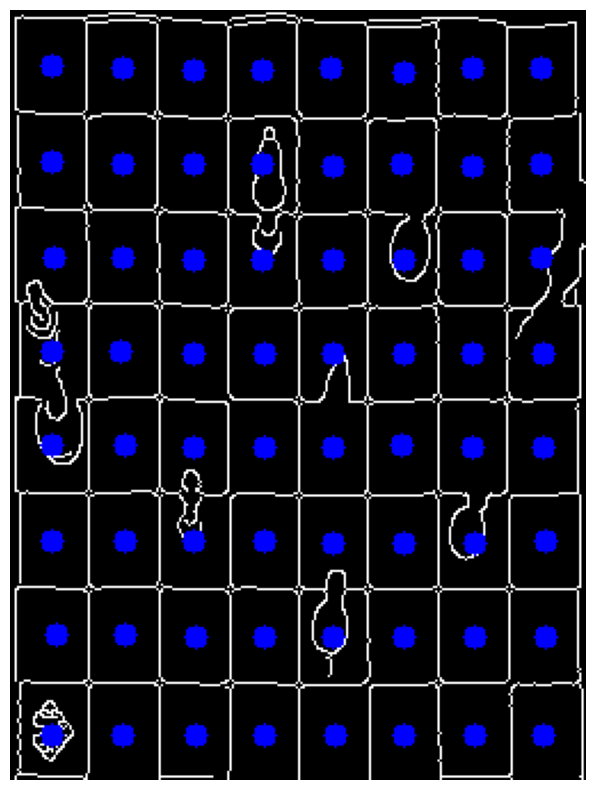

In [81]:
# Fill missing squares
for r in range(len(board_rows)):
    if len(board_rows[r]) < 8:
        print(f"Row {r} has {len(board_rows[r])} squares, filling missing squares...")

        row = board_rows[r]
        # Find the minimum x-difference between squares in the row
        min_x_diff = min(abs(row[j][0] - row[j + 1][0]) for j in range(len(row) - 1))
        # Find the average y-coordinate of the row
        avg_y = int(sum(coord[1] for coord in row) / len(row))

        # Check if its missing squares at the end of the row
        max_last_x = max(row[-1][0] for row in board_rows)
        last_square_diff = abs(row[-1][0] - max_last_x)
        while (last_square_diff > min_x_diff * 0.5) and len(board_rows[r]) < 8:
            new_square = [row[-1][0] + min_x_diff, avg_y]
            board_rows[r].append(new_square)
            print(f"Inserted missing square at rows end: {new_square}")
            last_square_diff = abs(board_rows[r][-1][0] - max_last_x)

        # Check if its missing squares at the start of the row
        min_first_x = min(row[0][0] for row in board_rows)
        first_square_diff = abs(row[0][0] - min_first_x)
        while (first_square_diff > min_x_diff * 0.5) and len(board_rows[r]) < 8:
            new_square = [row[0][0] - min_x_diff, avg_y]
            board_rows[r].insert(0, new_square)
            print(f"Inserted missing square at rows start: {new_square}")
            first_square_diff = abs(board_rows[r][0][0] - min_first_x)
            
        # Check if its missing squares in the middle of the row
        while len(board_rows[r]) < 8:
            row = board_rows[r]
            for i in range(1, len(row)): 
                col_diff = row[i][0] - row[i - 1][0]
                if abs(col_diff) > min_x_diff * 1.5:
                    new_square = [row[i - 1][0] + min_x_diff, avg_y]
                    board_rows[r].insert(i, new_square)
                    print(f"Inserted missing square at rows index {i}: {new_square}")
                    break

# Draw the final board with filled squares
board_filled = edges.copy()
board_filled = cv2.cvtColor(board_filled, cv2.COLOR_GRAY2BGR)  
for row in board_rows:
    for square in row:
        cv2.circle(board_filled, (int(square[0]), int(square[1])), 5, (255, 0, 0), -1)

show_image(board_filled)
